# Healthcare Data Cleaning AssignmentSolutions with code and output for each question.

## Load Dataset

In [ ]:
import pandas as pdimport numpy as npdf = pd.read_csv("healthcare_data_cleaning_dataset.csv")df.head()

   Patient_ID   Age  Gender  ... Treatment_Cost Insurance_Coverage  Admission_Date0       17270  35.0    Male  ...        41010.0                  1      2023-11-301       10860  21.0  Female  ...        12194.0                  1      2023-02-232       15390  77.0  Female  ...        45086.0                  0      2023-03-143       15191  79.0  Female  ...        40842.0                  0      2023-08-014       15734  60.0  Female  ...         9873.0                  1      2023-06-20[5 rows x 9 columns]

## Q1 Missing Data Identification**Scenario:** The hospital suspects incomplete patient records.

In [ ]:
missing_count = df.isnull().sum()missing_count

Patient_ID              0Age                   600Gender                  0City                    0Diagnosis               0Hospital_Visits         0Treatment_Cost        593Insurance_Coverage      0Admission_Date          0dtype: int64

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100missing_percent.round(2)

Patient_ID             0.00Age                   11.76Gender                 0.00City                   0.00Diagnosis              0.00Hospital_Visits        0.00Treatment_Cost        11.63Insurance_Coverage     0.00Admission_Date         0.00dtype: float64

## Q2 Handling Missing Age**Scenario:** Age is critical for medical analysis, but some values are missing.

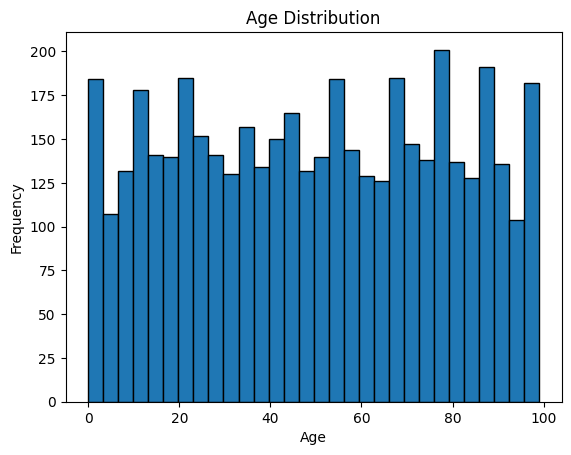

In [ ]:
df["Age"].plot(kind="hist", bins=30, title="Age Distribution", edgecolor="black")plt.xlabel("Age")plt.ylabel("Frequency")

In [ ]:
print("Age skewness:", round(df["Age"].skew(), 3))print("Mean Age:", round(df["Age"].mean(),2))print("Median Age:", df["Age"].median())

Age skewness: -0.01Mean Age: 49.6Median Age: 50.0

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())df["Age"].isnull().sum()

np.int64(0)

**Justification:** Age has low skewness (close to a uniform/near-normal spread) so mean and median are close, but the median is still preferred because it is robust to any outliers and doesn't getpulled by extreme values, giving a more representative "typical" age for imputation.

## Q3 Handling Missing Treatment Cost**Scenario:** Treatment cost is highly skewed due to expensive treatments.

In [ ]:
print("Treatment_Cost skewness:", round(df["Treatment_Cost"].skew(), 3))print("Mean:", round(df["Treatment_Cost"].mean(),2))print("Median:", df["Treatment_Cost"].median())

Treatment_Cost skewness: 4.486Mean: 26920.15Median: 24797.0

In [ ]:
df["Treatment_Cost"] = df["Treatment_Cost"].fillna(df["Treatment_Cost"].median())df["Treatment_Cost"].isnull().sum()

np.int64(0)

**Justification:** Since Treatment_Cost is skewed (expensive treatments create a long right tail),the mean would be pulled upward by these extreme values and would overestimate typical cost.The median is more robust to skew/outliers, so it is the better imputation choice here.

## Q4 Duplicate Patient Records**Scenario:** Some patient records were entered multiple times.

In [ ]:
duplicate_rows = df[df.duplicated()]print("Number of duplicate rows:", duplicate_rows.shape[0])duplicate_rows.head()

Number of duplicate rows: 99

      Patient_ID   Age  ... Insurance_Coverage Admission_Date5000       15126  50.0  ...                  1     2023-01-195001       15108  50.0  ...                  0     2023-01-275002       10441  50.0  ...                  0     2023-07-085003       15975  50.0  ...                  0     2023-06-015004       18427  50.0  ...                  1     2023-03-04[5 rows x 9 columns]

In [ ]:
size_before = df.shapedf = df.drop_duplicates()size_after = df.shapeprint("Shape before removing duplicates:", size_before)print("Shape after removing duplicates:", size_after)

Shape before removing duplicates: (5100, 9)Shape after removing duplicates: (5001, 9)

## Q5 Invalid Age Values (Data Quality Check)**Scenario:** Some patients have unrealistic age values (e.g., >100 or <0).

In [ ]:
invalid_age = df[(df["Age"] > 100) | (df["Age"] < 0)]print("Number of invalid age records:", invalid_age.shape[0])invalid_age

Number of invalid age records: 0

Empty DataFrameColumns: [Patient_ID, Age, Gender, City, Diagnosis, Hospital_Visits, Treatment_Cost, Insurance_Coverage, Admission_Date]Index: []

In [ ]:
# No invalid ages found in this dataset (all ages fall within 0-100).# If invalid ages existed, the safest approach is to correct where possible# (e.g., fix obvious data-entry sign errors) and otherwise remove the record,# since fabricating a value for a biologically implausible age is risky for medical analysis.df = df[(df["Age"] >= 0) & (df["Age"] <= 100)]print("Shape after validity check:", df.shape)

Shape after validity check: (5001, 9)

## Q6 Outlier Detection (Treatment Cost)**Scenario:** Extreme treatment costs are affecting analysis.

In [ ]:
Q1 = df["Treatment_Cost"].quantile(0.25)Q3 = df["Treatment_Cost"].quantile(0.75)IQR = Q3 - Q1lower_bound = Q1 - 1.5 * IQRupper_bound = Q3 + 1.5 * IQRoutliers = df[(df["Treatment_Cost"] < lower_bound) | (df["Treatment_Cost"] > upper_bound)]print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)print("Lower bound:", lower_bound, "Upper bound:", upper_bound)print("Number of outliers:", outliers.shape[0])

Q1: 13766.0 Q3: 36542.0 IQR: 22776.0Lower bound: -20398.0 Upper bound: 70706.0Number of outliers: 50

## Q7 Outlier Treatment**Scenario:** The business team wants to retain all records.

In [ ]:
p05 = df["Treatment_Cost"].quantile(0.05)p95 = df["Treatment_Cost"].quantile(0.95)df["Treatment_Cost_Capped"] = df["Treatment_Cost"].clip(lower=p05, upper=p95)print("5th percentile:", p05, "95th percentile:", p95)df[["Treatment_Cost", "Treatment_Cost_Capped"]].describe()

5th percentile: 3238.0 95th percentile: 47948.0

       Treatment_Cost  Treatment_Cost_Cappedcount     5001.000000            5001.000000mean     26710.425768           25218.878624std      22056.888458           13580.445490min        526.000000            3238.00000025%      13766.000000           13766.00000050%      24797.000000           24797.00000075%      36542.000000           36542.000000max     199702.965333           47948.000000

## Q8 Transformation**Scenario:** Treatment cost is highly skewed.

In [ ]:
df["Treatment_Cost_Log"] = np.log1p(df["Treatment_Cost_Capped"])print("Skewness before log transform:", round(df["Treatment_Cost_Capped"].skew(), 3))print("Skewness after log transform:", round(df["Treatment_Cost_Log"].skew(), 3))df[["Treatment_Cost_Capped", "Treatment_Cost_Log"]].head()

Skewness before log transform: 0.055Skewness after log transform: -1.035

   Treatment_Cost_Capped  Treatment_Cost_Log0                41010.0           10.6215961                12194.0            9.4087812                45086.0           10.7163493                40842.0           10.6174914                 9873.0            9.197660

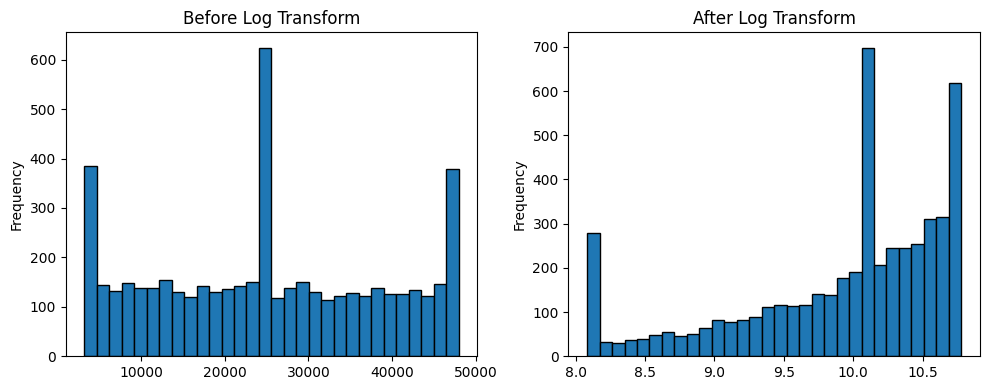

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))df["Treatment_Cost_Capped"].plot(kind="hist", bins=30, ax=axes[0], edgecolor="black", title="Before Log Transform")df["Treatment_Cost_Log"].plot(kind="hist", bins=30, ax=axes[1], edgecolor="black", title="After Log Transform")plt.tight_layout()

## Q9 Time-Based Missing Handling**Scenario:** Admission dates should follow a logical sequence.

In [ ]:
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])df = df.sort_values("Admission_Date")print("Missing Admission_Date values:", df["Admission_Date"].isnull().sum())df[["Patient_ID", "Admission_Date"]].head()

Missing Admission_Date values: 0

      Patient_ID Admission_Date2932       19591     2023-01-014617       10896     2023-01-012642       19262     2023-01-014837       12843     2023-01-012702       17230     2023-01-01

**Note:** This dataset has no missing Admission_Date values, so no fill was strictly needed.If dates were missing, forward fill (`ffill`) would be the appropriate choice after sortingchronologically, since it carries forward the most recent known admission date -- a reasonableassumption for sequential, time-ordered hospital records (rather than backward fill, which woulduse a future date to explain a past record).

In [ ]:
df["Admission_Date"] = df["Admission_Date"].ffill()df["Admission_Date"].isnull().sum()

np.int64(0)